<a href="https://colab.research.google.com/github/alessysantos/Bayesian-Statistics/blob/main/SUPERVISED%26UNSUPERVISED_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original DataFrame head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



--- Classification Algorithm ---

Classification Results:
Model Predictions (first 10): [1 0 0 0 0 1 0 0 0 0]
Actual Values (first 10): [0 0 0 0 0 1 0 0 0 1]
Model Accuracy: 0.8

--- Clustering Algorithm ---

Cluster distribution:


,count
cluster,
1,19
0,17
2,14


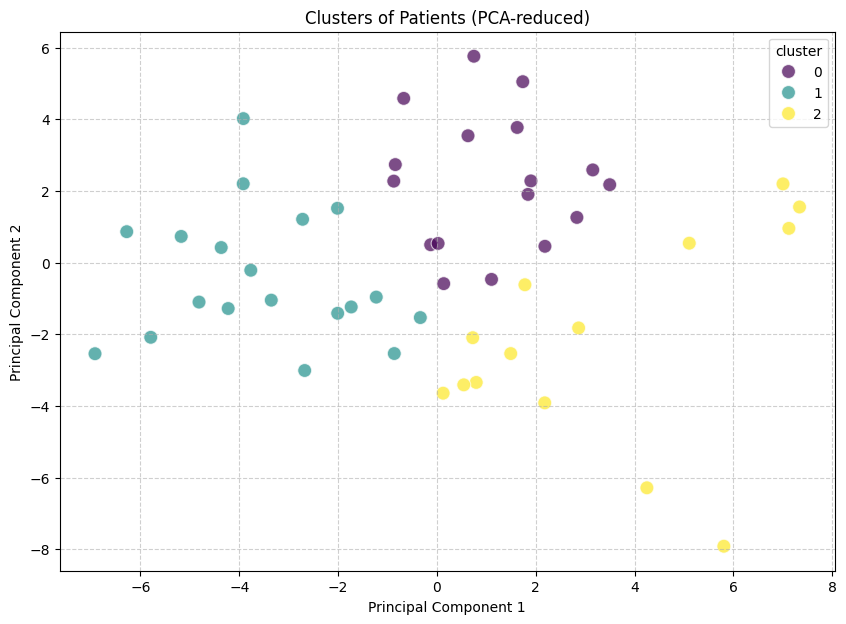

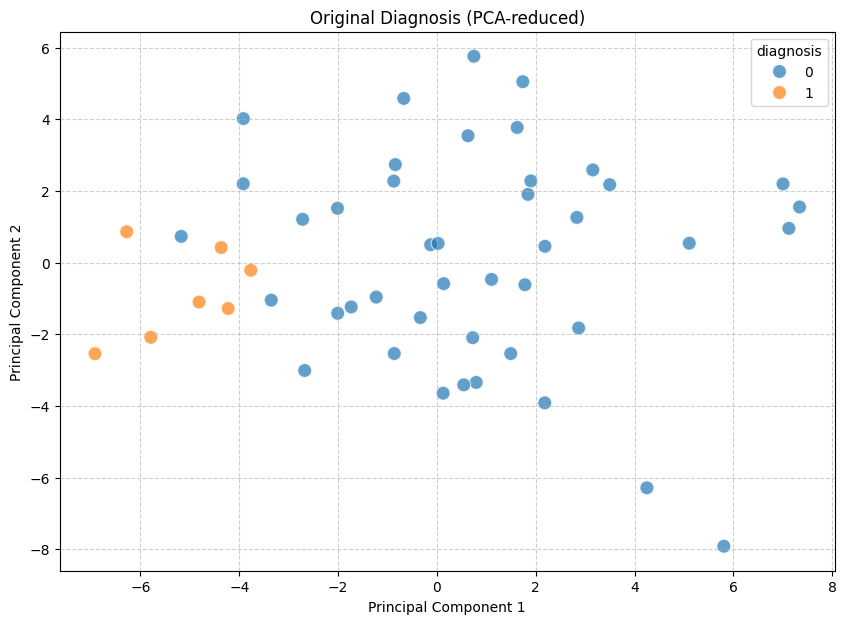

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


df = pd.read_excel('CANCER PATIENT DATA.xlsx')
print("Original DataFrame head:")
display(df.head())

print("\n--- Classification Algorithm ---")
X_clf = df.drop('diagnosis', axis=1)
y_clf = df['diagnosis']

encoder = LabelEncoder()
y_encoded_clf = encoder.fit_transform(y_clf)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_encoded_clf, test_size=0.2, random_state=42
)

model_clf = DecisionTreeClassifier(random_state=42)
model_clf.fit(X_train_clf, y_train_clf)

predictions_clf = model_clf.predict(X_test_clf)
accuracy_clf = accuracy_score(y_test_clf, predictions_clf)

print("\nClassification Results:")
print("Model Predictions (first 10):", predictions_clf[:10])
print("Actual Values (first 10):", y_test_clf[:10])
print("Model Accuracy:", accuracy_clf)

print("\n--- Clustering Algorithm ---")

scaler = StandardScaler()
X_scaled_clus = scaler.fit_transform(X_clf)


kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_clus = kmeans.fit_predict(X_scaled_clus)

df['cluster'] = clusters_clus

print("\nCluster distribution:")
display(df['cluster'].value_counts())

pca = PCA(n_components=2)
X_pca_clus = pca.fit_transform(X_scaled_clus)

pca_df_clus = pd.DataFrame(data = X_pca_clus, columns = ['principal component 1', 'principal component 2'])
pca_df_clus['cluster'] = clusters_clus
pca_df_clus['diagnosis'] = y_encoded_clf

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='principal component 1',
    y='principal component 2',
    hue='cluster',
    data=pca_df_clus,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Clusters of Patients (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='principal component 1',
    y='principal component 2',
    hue='diagnosis',
    data=pca_df_clus,
    palette='tab10',
    s=100,
    alpha=0.7
)
plt.title('Original Diagnosis (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()